# Question 1

In [124]:
goldenrod = read.csv("Goldenrod.csv")
goldenrod = na.omit(goldenrod)
head(goldenrod)

,Gdiam03,Stdiam03,Wall03,Fate03,Gdiam04,Stdiam04,Wall04,Fate04,Fly04
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,21.7,3.6,7.3,f,23.1,3.7,9.4,f,y
3,20.5,3.5,7.8,f,19.4,3.9,6.6,b,n
5,19.5,3.9,7.1,u,23.5,3.5,9.2,f,y
6,18.1,4.7,7.1,b,22.6,3.5,7.8,f,y
7,23.0,4.9,8.6,f,11.6,4.5,4.3,f,y
8,26.5,4.8,10.5,f,25.2,4.5,9.6,b,n


## Part (a)

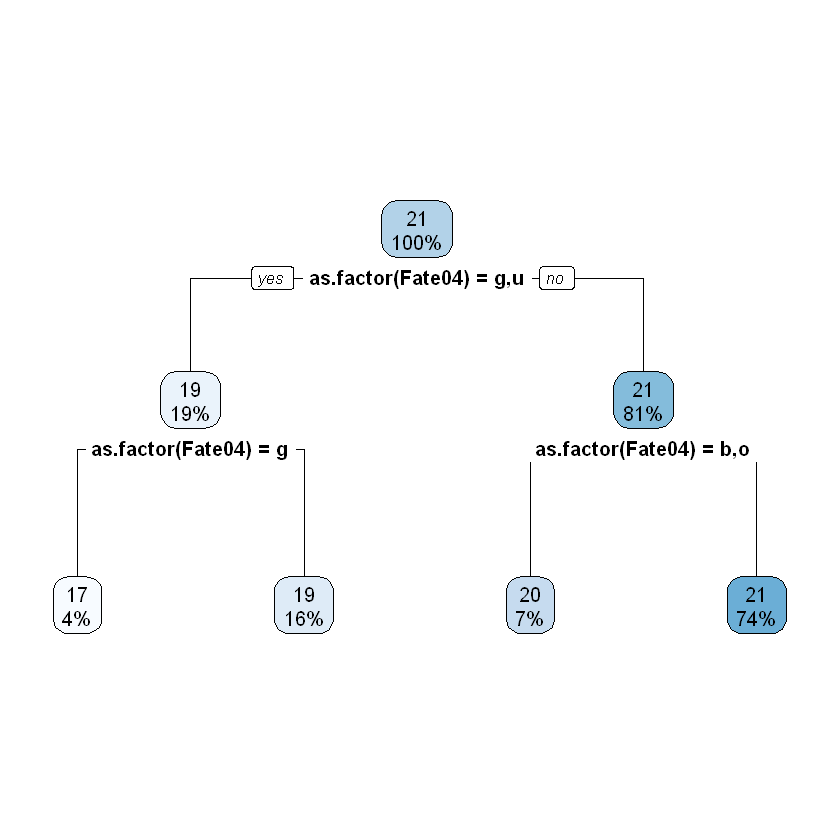

In [131]:
library(rpart)
m = rpart(Gdiam04~as.factor(Fate04), data=goldenrod, cp=0.001)
library(rattle)
library(rpart.plot)
rpart.plot(m)

In [132]:
predicted <- predict(m, goldenrod)
mean((predicted-goldenrod$Gdiam04)^2)

[1] 7.995015

## Part (b)

In [137]:
summary(aov(Gdiam04~Fate04, data=goldenrod))

             Df Sum Sq Mean Sq F value   Pr(>F)    
Fate04        4    652  163.07   20.21 1.67e-15 ***
Residuals   528   4260    8.07                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Null hypothesis: Fate04 has no effect on Gdiam04

F-value: 20.21

P-value: 0+

Conclusion: Reject Null: Fate04 does have an effect

## Part (c)

In [138]:
summary(aov(Gdiam04~Fly04, data=goldenrod))

             Df Sum Sq Mean Sq F value   Pr(>F)    
Fly04         1    446   445.7   52.99 1.21e-12 ***
Residuals   531   4466     8.4                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running the same test with Fly04 also gives a statistically significant result, so that also has an effect on gall size.

## Part (d)

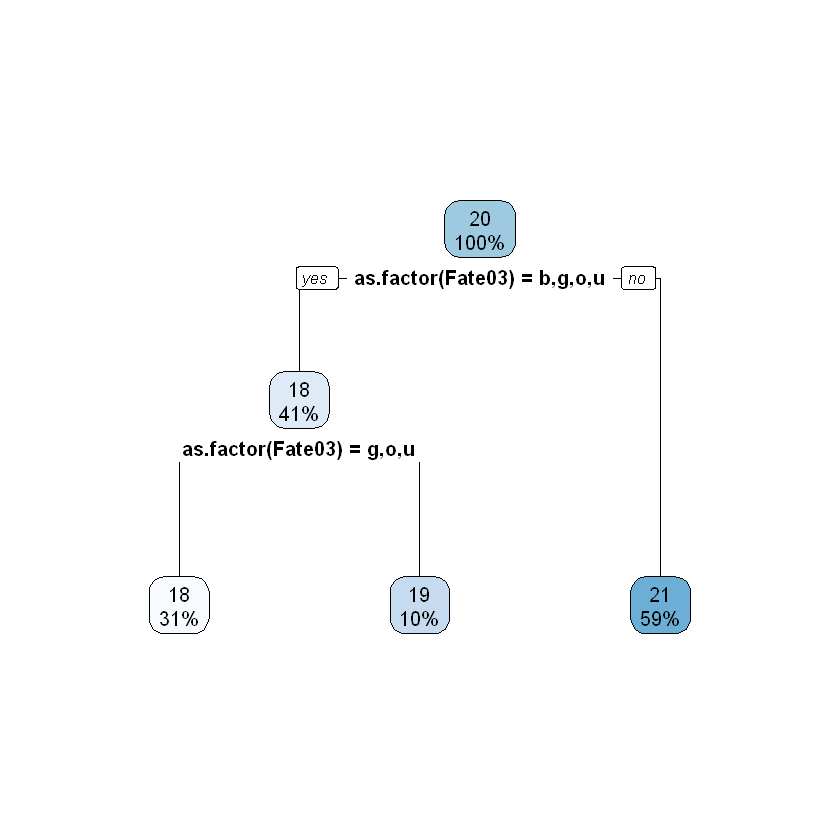

In [139]:
library(rpart)
m = rpart(Gdiam03~as.factor(Fate03), data=goldenrod, cp=0.001)
library(rattle)
library(rpart.plot)
rpart.plot(m)

In [140]:
predicted <- predict(m, goldenrod)
mean((predicted-goldenrod$Gdiam04)^2)

[1] 12.75838

The decision tree looks very different for 2003 then 2004, and the MSE is also comparitively higher (given that numbers in Gdiam03 are small and close together).

## Part (e)

We could use another decision tree to analyze the effect of year as well, because looking at the split tells us a lot about what class tends to predict what.

# Question 2

In [146]:
medgpa = read.csv("MedGPA.csv")
print(head(medgpa))

  Accept Acceptance Sex BCPM  GPA VR PS WS BS MCAT Apps
1      D          0   F 3.59 3.62 11  9  9  9   38    5
2      A          1   M 3.75 3.84 12 13  8 12   45    3
3      A          1   F 3.24 3.23  9 10  5  9   33   19
4      A          1   F 3.74 3.69 12 11  7 10   40    5
5      A          1   F 3.53 3.38  9 11  4 11   35   11
6      A          1   M 3.59 3.72 10  9  7 10   36    5


## Part (a)

In [3]:
log = glm(Acceptance~MCAT, data=medgpa, family="binomial")
summary(log)


Call:
glm(formula = Acceptance ~ MCAT, family = "binomial", data = medgpa)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept) -8.71245    3.23645  -2.692  0.00710 **
MCAT         0.24596    0.08938   2.752  0.00592 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 75.791  on 54  degrees of freedom
Residual deviance: 64.697  on 53  degrees of freedom
AIC: 68.697

Number of Fisher Scoring iterations: 4


\begin{align}
logit(\text{MCAT}) &= -8.71245 +  0.24596\cdot\text{MCAT}\\
\\
p(\text{MCAT})&= \dfrac{e^{-8.71245 +  0.24596\cdot\text{MCAT}}}{1+e^{-8.71245 +  0.24596\cdot\text{MCAT}}}
\end{align}

# Part (b)

\begin{align}
p(40) &= \dfrac{e^{-8.71245 +  0.24596\cdot40}}{1+e^{-8.71245 +  0.24596\cdot40}}\\
&\approx \boxed{0.755} 
\end{align}

The model says that a student with MCAT 40 is estimated to have 75.5% probability of getting accepted into med school.

## Part (c)

A 50-50 chance of getting into med school is equivalent to $logit(\text{MCAT}) = 0$. We can solve this equation for the MCAT score to get:
\begin{align}
logit(\text{MCAT}) &= -8.71245 +  0.24596\cdot\text{MCAT} = 0\\
MCAT &= \dfrac{8.71245}{0.24596} \approx \boxed{35}
\end{align}

## Part (d)

In [4]:
anova(log, test="Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,54,75.79102,NA
MCAT,1,11.09353,53,64.69749,0.0008662948


We can conduct a nested G test to see how well the model fits the data. Our p-value is $9\times10^{-4}<0.05$ so there is a statistically significant relationship between MCAT and acceptance into medical school.

## Part (e)

In [7]:
print(exp(confint(log, parm="MCAT")))

Waiting for profiling to be done...



   2.5 %   97.5 % 
1.094072 1.554676 


This syas that we are 95% confident that the actual odds ratio for MCAT is in the range (1.09, 1.56). The odds ratio represents the fold-change in probability of getting accpeted for every 1 unit increase in the MCAT score. Since the value 1 is not contained within the interval, we are 95% confident that a higher MCAT score increases the chance of getting accepted.

# Part (f)

In [28]:
MALE = medgpa[medgpa$Sex == "M",]
male = glm(Acceptance~MCAT, data=MALE, family="binomial")

FEMALE = medgpa[medgpa$Sex == "F",]
female = glm(Acceptance~MCAT, data=FEMALE, family="binomial")

In [31]:
print(exp(confint(male, parm="MCAT")))

Waiting for profiling to be done...



   2.5 %   97.5 % 
1.114486 2.043887 


In [32]:
print(exp(confint(female, parm="MCAT")))

Waiting for profiling to be done...



    2.5 %    97.5 % 
0.9756265 1.5884135 


I first trained two models on only male data dn only female data and compared the log odds estimated. As we can see females tend have much lower odds than males, although tehre is overlap between the intervals. Still there does appear to be a slight difference in predicting acceptance for MCAT scores between genders.

# Question 3

In [35]:
shaka = read.csv("Shaka.csv")
head(shaka)

,player,time,activity,day,order,rate
,<int>,<int>,<int>,<int>,<int>,<int>
1,1,1,1,1,2,98
2,1,1,1,2,1,94
3,1,1,1,3,3,98
4,1,1,2,1,1,84
5,1,1,2,2,2,84
6,1,1,2,3,1,84


## Part (a)

In [92]:
model1 = lm(rate~as.factor(player)+as.factor(activity), data=shaka)
summary(model1)


Call:
lm(formula = rate ~ as.factor(player) + as.factor(activity), 
    data = shaka)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.1778  -2.8000   0.3111   2.8000  13.4222 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)            96.133      1.389  69.223  < 2e-16 ***
as.factor(player)2      7.444      1.660   4.485 2.32e-05 ***
as.factor(player)3     34.667      1.660  20.885  < 2e-16 ***
as.factor(player)4     -5.556      1.660  -3.347  0.00123 ** 
as.factor(player)5     15.444      1.660   9.305 1.61e-14 ***
as.factor(activity)2  -11.400      1.286  -8.867 1.21e-13 ***
as.factor(activity)3   13.000      1.286  10.111 3.96e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.98 on 83 degrees of freedom
Multiple R-squared:  0.9284,	Adjusted R-squared:  0.9232 
F-statistic: 179.4 on 6 and 83 DF,  p-value: < 2.2e-16


My paramaters are simply player and activity, although there are numerous dummy variables to accound for the fact that they are factors. We assume the standard assumptions of linear regression (discusssed more in the next part)

## Part (b)

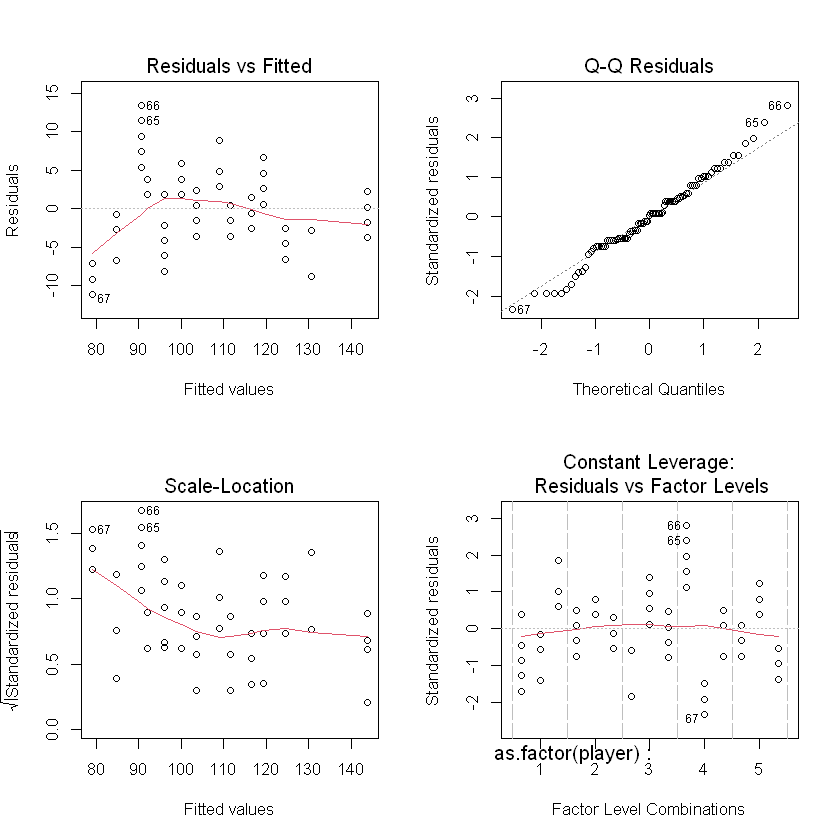

In [86]:
par(mfrow=c(2,2))
plot(model1)

The residual plots do not seem to indicate homoscedasticityand the residuals seem normally distributed byt he QQ plot. No point has a high studentized residual (greater than 3) and the leverages are constant (so no point skews the data a lot).

## Part (c)

The $R^2$ term provides an appropriate goodness-of-fit measure for linear regression. The value is around 0.93 which is quite high, providing evidence that our model fits the data well.

## Part (d)

Yes, as indicated above the data seems to linear due to thigh $R^2$ term, the residuals are normally distributed, and the data is not homeoscedastic.

## Part (e)

In [93]:
summary(model1)


Call:
lm(formula = rate ~ as.factor(player) + as.factor(activity), 
    data = shaka)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.1778  -2.8000   0.3111   2.8000  13.4222 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)            96.133      1.389  69.223  < 2e-16 ***
as.factor(player)2      7.444      1.660   4.485 2.32e-05 ***
as.factor(player)3     34.667      1.660  20.885  < 2e-16 ***
as.factor(player)4     -5.556      1.660  -3.347  0.00123 ** 
as.factor(player)5     15.444      1.660   9.305 1.61e-14 ***
as.factor(activity)2  -11.400      1.286  -8.867 1.21e-13 ***
as.factor(activity)3   13.000      1.286  10.111 3.96e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.98 on 83 degrees of freedom
Multiple R-squared:  0.9284,	Adjusted R-squared:  0.9232 
F-statistic: 179.4 on 6 and 83 DF,  p-value: < 2.2e-16


As indicated inthe summary all of the terms in the linear regression are significant to 0.01 (and all but one are significant to 0.001). This means our linear regression fits the data well and each term is used to determine the prediction.